<img src="./logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Yugra Yoseli
### 1er Cuatrimestre 2026

## Consigna
    Ejercicio 1:  
    Sintetizar:

    Señal sinusoidal de 2 KHz.
    Misma señal amplificada 3 dB y desfasada en π/2.
    Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.
    Misma señal con efecto de saturación al 75% de su amplitud. Ayuda: ver numpy.clip().
    Una señal cuadrada de 4KHz.
    Un pulso rectangular de 10ms.
    En cada caso indique: período, número de muestras y si se trata de una señal de potencia o energía según corresponda.

    Ejercicio 2: 

    Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:

    a) x[n] = cos(ω₀.n. TS). Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

    b) x[n] = (1/2)ⁿ u[n].

    c) x[n] = u[n + 1] - u[n - 2].

# Introducción

 En este trabajo se presenta la síntesis de señales discretas en Python, usando de base la señal anteriormente ejecutada en la TS0, se generaron seis tipos de señales aplicando distintas modificaciones como la amplitud, desfasaje, modulacion en amplitud y saturación.
 Las señales se obtienen mediante muestreo uniforme, utilizando una frecuencia de muestreo fs=20000 Hz, a su vez se determinó el período, el número de muestras utilizadas y si se trata de una señal de potencia o de energía.
 El objetivo de esta práctica es comprender cómo se representan las señales en tiempo discreto y cómo las distintas operaciones afectan su forma y sus características.

    

# Ejercicio 1:
## Código y sus respectivos gráficos


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
#%% Función para generar una senoidal
def mi_sen(vmax, dc, ff, ph, nn, fs):
    Ts = 1 / fs                      # tiempo entre muestras
    tt = np.arange(nn) * Ts          # vector de tiempo
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

#%% Parámetros generales
fs = 20000          # frecuencia de muestreo
Ts = 1 / fs
f0 = 2000           # frecuencia de la señal base: 2 kHz
N = 100             # cantidad de muestras para que los gráficos se vean mejor



Cada una de las señales pedidas y sus respectivos gráficos

SEÑAL 1
Período = 0.0005 s
Número de muestras = 100
Es una señal de potencia
Potencia = 0.49999999999999983


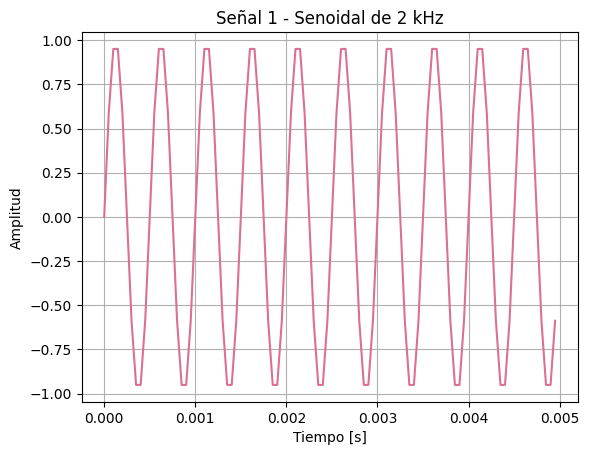

In [15]:
#%% Señal 1: senoidal de 2 kHz
tt1, xx1 = mi_sen(vmax=1, dc=0, ff=f0, ph=0, nn=N, fs=fs)

T1 = 1 / f0
Pot1 = np.mean(xx1**2) #La potencia de una señal discreta se calcula como el promedio del cuadrado de sus muestras.

print("SEÑAL 1")
print("Período =", T1, "s")
print("Número de muestras =", N)
print("Es una señal de potencia")
print("Potencia =", Pot1)

plt.figure()
plt.plot(tt1, xx1, color='palevioletred')
plt.title("Señal 1 - Senoidal de 2 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


En la señal 1 se observa una señal sinusoidal con forma periódica y amplitud constante. 
La señal presenta una oscilación suave con periodo constante.


SEÑAL 2
Período = 0.0005 s
Número de muestras = 100
Es una señal de potencia ya que es periodica
Potencia = 0.9976311574844401 W


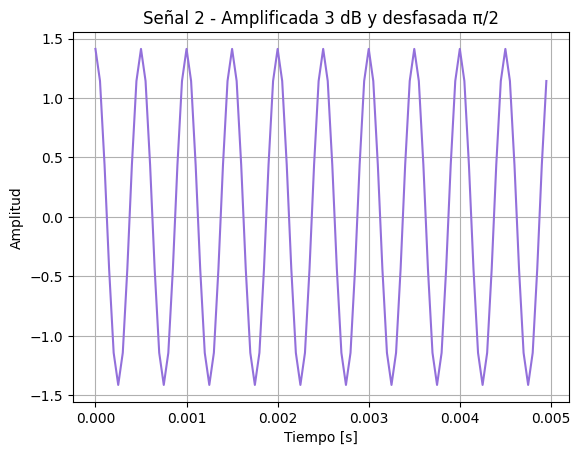

In [16]:
#%% Señal 2: misma señal amplificada 3 dB y desfasada pi/2
A = 10**(3/20)   # ganancia en amplitud para 3 dB, dB=20log(A)

tt2, xx2 = mi_sen(vmax=A, dc=0, ff=f0, ph=np.pi/2, nn=N, fs=fs)

T2 = 1 / f0
Pot2 = np.mean(xx2**2)

print("\nSEÑAL 2")
print("Período =", T2, "s")
print("Número de muestras =", N)
print("Es una señal de potencia ya que es periodica")
print("Potencia =", Pot2, "W")

plt.figure()
plt.plot(tt2, xx2, color='mediumpurple')
plt.title("Señal 2 - Amplificada 3 dB y desfasada π/2")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


En la señal 2 se observa una señal sinusoidal desfasada pero manteniendo su periodicidad, amplitud constante, periodo constante y suavidad. 


SEÑAL 3
Período = 1e-07 s
Número de muestras = 20000


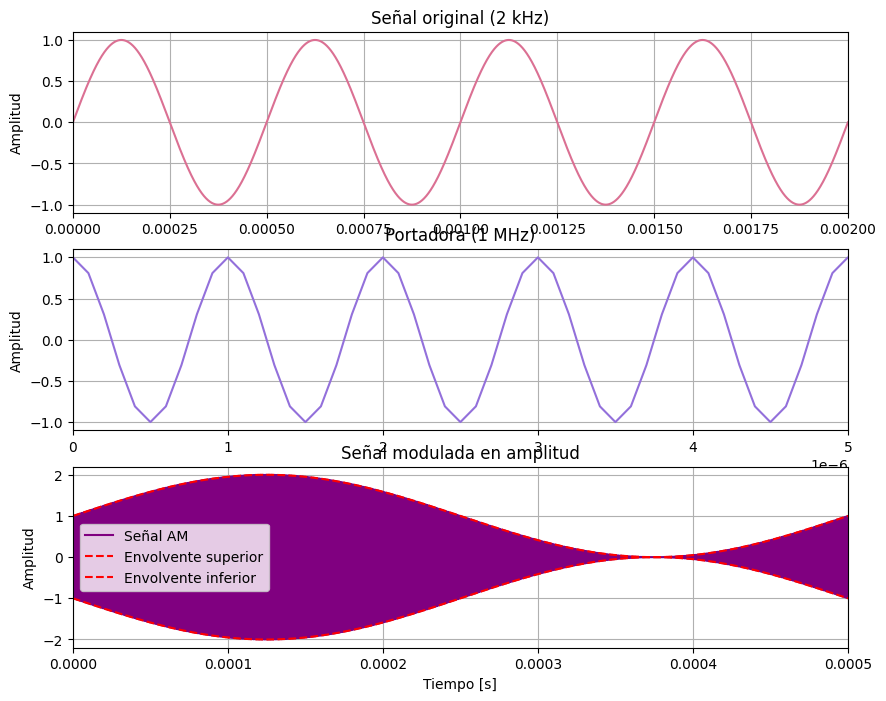

In [17]:
#%%3. Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 kHz.

fs3 = 10000000          # frecuencia de muestreo alta (10 MHz)
Ts3 = 1 / fs3
duracion = 0.002        # 2 ms en segundos
N3 = int(fs3 * duracion)    

# Señal original de 2 kHz
tt3, xx3 = mi_sen(vmax=1, dc=0, ff=2000, ph=0, nn=N3, fs=fs3)

# Señal portadora de 1 MHz
fc = 1_000_000
_, portadora = mi_sen(vmax=1, dc=0, ff=fc, ph=np.pi/2, nn=N3, fs=fs3)

# Modulación en amplitud
y = (1 + xx3) * portadora
print("\nSEÑAL 3")
print("Período =", Ts3, "s")
print("Número de muestras =", N3)
plt.figure(figsize=(10,8))

# Señal original
plt.subplot(3,1,1)
plt.plot(tt3, xx3, color='palevioletred')
plt.xlim(0, 0.002)
plt.title("Señal original (2 kHz)")
plt.ylabel("Amplitud")
plt.grid(True)

# Portadora
plt.subplot(3,1,2)
plt.plot(tt3, portadora, color='mediumpurple')
plt.xlim(0, 5e-6)
plt.title("Portadora (1 MHz)")
plt.ylabel("Amplitud")
plt.grid(True)

# Señal modulada
plt.subplot(3,1,3)
plt.plot(tt3, y, color='purple', label="Señal AM")
plt.xlim(0, 0.0005)
plt.plot(tt3, (1+xx3), 'r--', label="Envolvente superior")
plt.plot(tt3, -(1+xx3), 'r--', label="Envolvente inferior")

plt.title("Señal modulada en amplitud")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)


Para este ítem se implementó una modulación en amplitud (AM) de la forma:

**y(t) = (1 + m(t)) · c(t)**

Donde m(t) es la señal de 2 kHz que actúa como moduladora y c(t) es la señal portadora de 1 MHz encargada de transportar la información. El término "+1" evita la sobremodulación, garantizando que la envolvente no cambie de signo.

En el gráfico se observa que la amplitud de la portadora varía en el tiempo siguiendo la forma de la señal moduladora, lo que corresponde al principio de la modulación en amplitud. Las líneas punteadas representan la envolvente ±(1 + m(t)), y se verifica que la señal modulada queda contenida dentro de ellas en todo momento.

Debido a que la portadora es de 1 MHz, por el criterio de Nyquist se requiere una frecuencia de muestreo fs > 2 MHz. Para este ítem se utilizó fs = 10 MHz, distinta a la empleada en los casos anteriores, donde una frecuencia mucho menor era suficiente.

Como la señal moduladora y portadora son periodicas, la modulada tambien lo es, definiendose como una señal de potencia.


SEÑAL 4
Período = 0.0005 s
Número de muestras = 100
Es una señal de potencia por ser periodica
Potencia = 0.3417110129921933 W


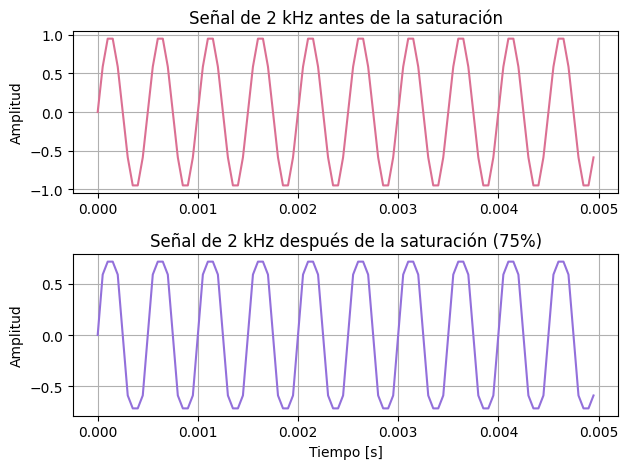

In [18]:
#%% Señal 4: señal de 2 kHz con saturación al 75%
tt4 = tt1
xx_original = xx1

limite = 0.75 * np.max(np.abs(xx_original))
xx4 = np.clip(xx_original, -limite, limite)

Pot4 = np.mean(xx4**2)

print("\nSEÑAL 4")
print("Período =", 1/f0, "s")
print("Número de muestras =", N)
print("Es una señal de potencia por ser periodica")
print("Potencia =", Pot4, "W")

plt.figure()

plt.subplot(2,1,1)
plt.plot(tt4, xx_original, color='palevioletred')
plt.title("Señal de 2 kHz antes de la saturación")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(tt4, xx4, color='mediumpurple')
plt.title("Señal de 2 kHz después de la saturación (75%)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.tight_layout()
plt.show()

En estos gráficos se aplica una saturación al 75% sobre la señal de 2 kHz mediante np.clip(). En el gráfico se observa el recorte de los picos, volviéndose planos en los valores máximos y mínimos, indicando una limitación de amplitud. La saturación introduce distorsión en la señal, ya que se trata de una operación no lineal.


SEÑAL 5
Período = 0.00025 s
Número de muestras = 100
Es una señal de potencia
Potencia = 1.0 W


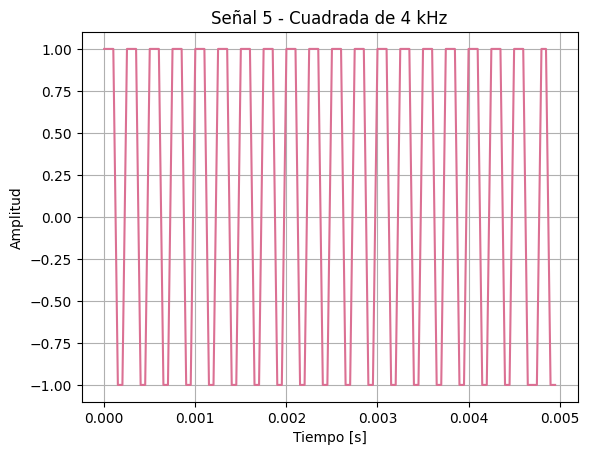

In [19]:
#%% Señal 5: señal cuadrada de 4 kHz
f5 = 4000
tt5 = np.arange(N) * Ts
xx5 = sig.square(2 * np.pi * f5 * tt5)

T5 = 1 / f5
Pot5 = np.mean(xx5**2)

print("\nSEÑAL 5")
print("Período =", T5, "s")
print("Número de muestras =", N)
print("Es una señal de potencia")
print("Potencia =", Pot5, "W")

plt.figure()
plt.plot(tt5, xx5, color='palevioletred')
plt.title("Señal 5 - Cuadrada de 4 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


Se observa una señal cuadrada de 4 kHz, caracterizada por cambios abruptos entre dos niveles. Como es una señal periódica, corresponde a una señal de potencia.


SEÑAL 6
Duración del pulso = 0.01 s
Número de muestras = 400
Es una señal de energía ya que es una señal finita


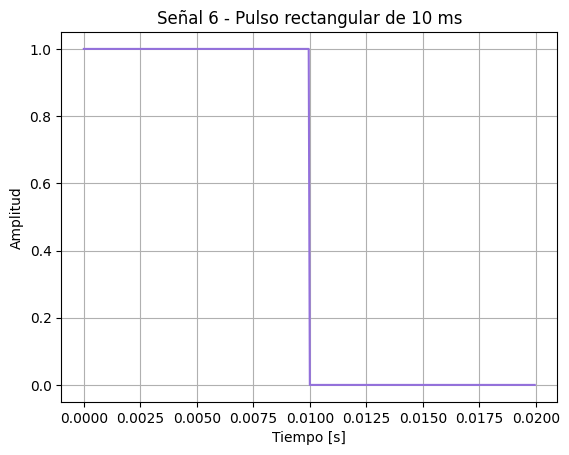

In [20]:
#%% Señal 6: pulso rectangular de 10 ms
duracion = 0.01
N6 = 400
tt6 = np.arange(N6) * Ts
xx6 = np.zeros(N6)

muestras_pulso = int(duracion * fs)
xx6[:muestras_pulso] = 1

print("\nSEÑAL 6")
print("Duración del pulso =", duracion, "s")
print("Número de muestras =", N6)
print("Es una señal de energía ya que es una señal finita")


plt.figure()
plt.plot(tt6, xx6, color='mediumpurple')
plt.title("Señal 6 - Pulso rectangular de 10 ms")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

Se observa un pulso rectangular de duración finita igual a 10 ms. La señal presenta un valor constante durante ese intervalo y luego se anula. Como se tratarse de una señal no periódica y acotada en el tiempo, se clasifica como una señal de energía.

## Conclusión problema 1

Las seis señales muestran cómo distintas operaciones sobre una señal de 2 kHz generan comportamientos diferentes. La amplificación y el desfase no alteran la forma senoidal, mientras que la modulación en amplitud introduce una envolvente sobre una portadora de alta frecuencia. La saturación recorta los picos y produce distorsión. Por otro lado, la señal cuadrada presenta transiciones abruptas y el pulso rectangular es el único caso no periódico, por lo que se clasifica como señal de energía. 

# Ejercicio 2:



 Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:

    a) x[n] = cos(ω₀.n. TS). Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

    b) x[n] = (1/2)ⁿ u[n].

    c) x[n] = u[n + 1] - u[n - 2].


## Item A


Primero desarrollo cada x[n] para sus respectivas y[n]

In [25]:
from IPython.display import IFrame
IFrame("Ejercicio2.pdf", width=1000, height=1000)

## Desarrollo del código y analisís de los gráficos

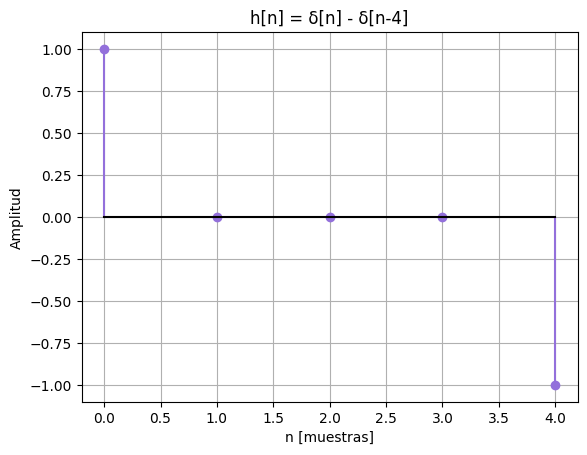

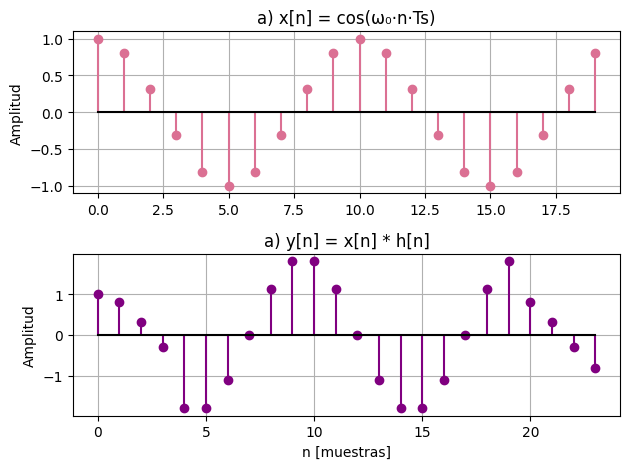

In [22]:
#%% PROBLEMA 2
w0 = 2 * np.pi * f0
 
#%% h[n] = delta[n] - delta[n-4]
h    = np.zeros(5)
h[0] =  1
h[4] = -1
# Gráfico de h[n]
plt.figure()
plt.stem(np.arange(len(h)), h, linefmt='mediumpurple', markerfmt='o', basefmt='k')
plt.title("h[n] = δ[n] - δ[n-4]")
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()
#%% INCISO a) x[n] = cos(w0*n*Ts)
N = 20
n = np.arange(N)
x_a = np.cos(w0 * n * Ts)
y_a = np.convolve(x_a, h)
 
plt.figure()
plt.subplot(2, 1, 1)
plt.stem(n, x_a, linefmt='palevioletred', markerfmt='o', basefmt='k')
plt.title("a) x[n] = cos(ω₀·n·Ts)")
plt.ylabel("Amplitud")
plt.grid(True)
 
plt.subplot(2, 1, 2)
plt.stem(np.arange(len(y_a)), y_a, linefmt='purple', markerfmt='o', basefmt='k')
plt.title("a) y[n] = x[n] * h[n]")
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.grid(True)
 
plt.tight_layout()
plt.show()
 

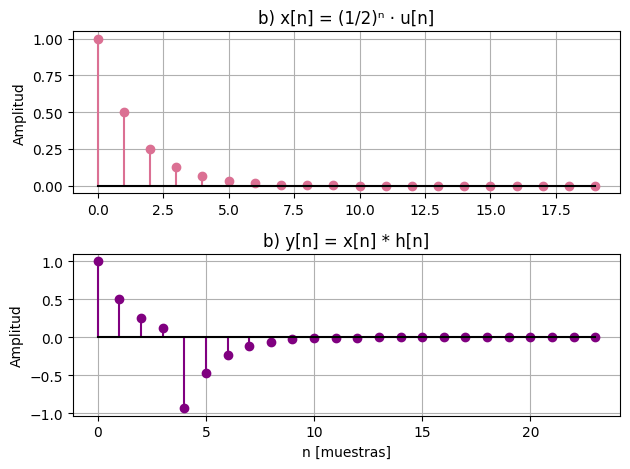

In [23]:
#%% INCISO b) x[n] = (1/2)^n * u[n]
n = np.arange(N)
x_b = (1/2)**n
y_b = np.convolve(x_b, h)
 
plt.figure()
plt.subplot(2, 1, 1)
plt.stem(n, x_b, linefmt='palevioletred', markerfmt='o', basefmt='k')
plt.title("b) x[n] = (1/2)ⁿ · u[n]")
plt.ylabel("Amplitud")
plt.grid(True)
 
plt.subplot(2, 1, 2)
plt.stem(np.arange(len(y_b)), y_b, linefmt='purple', markerfmt='o', basefmt='k')
plt.title("b) y[n] = x[n] * h[n]")
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.grid(True)
 
plt.tight_layout()
plt.show()

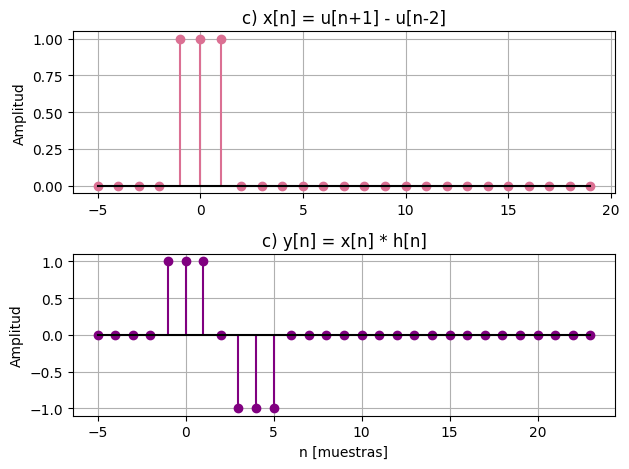

In [24]:
#%% INCISO c) x[n] = u[n+1] - u[n-2]
n = np.arange(-5, 20)
x_c = ((n >= -1) & (n <= 1)).astype(float)
y_c = np.convolve(x_c, h)
 
plt.figure()
plt.subplot(2, 1, 1)
plt.stem(n, x_c, linefmt='palevioletred', markerfmt='o', basefmt='k')
plt.title("c) x[n] = u[n+1] - u[n-2]")
plt.ylabel("Amplitud")
plt.grid(True)
 
plt.subplot(2, 1, 2)
plt.stem(np.arange(len(y_c)) + n[0], y_c, linefmt='purple', markerfmt='o', basefmt='k')
plt.title("c) y[n] = x[n] * h[n]")
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.grid(True)
 
plt.tight_layout()
plt.show()
 

## Conclusión Problema 2
Al analizar los tres casos se ve que el sistema siempre hace lo mismo: a la señal original le resta una copia atrasada 4 muestras, es decir
y[n] = x[n] - x[n-4].

En la señal senoidal esto hace que cambie su forma (amplitud y fase), pero sigue teniendo la misma frecuencia. En la exponencial, a partir de n=4 la señal empieza a hacerse negativa porque se le resta un valor mayor del pasado, y luego tiende a cero. En el pulso, se ve muy claro el efecto del sistema, ya que aparecen dos bloques: uno positivo y otro negativo desplazado.

En todos los casos también se observa que la salida es más larga que la entrada, ya que la convolución agrega muestras debido al retardo del sistema.